In [82]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
from tqdm.auto import tqdm
from dataclasses import dataclass, field, asdict
from typing import List
import json
import pandas as pd
import scanpy as sc

# ---------------------------------------------------------
# 1. Config: Anchor 관련 설정 추가
# ---------------------------------------------------------
@dataclass
class VAEConfig:
    input_dim: int
    cond_dim: int
    num_classes: int
    z_bio_dim: int = 32
    z_rest_dim: int = 16
    hidden_dims: List[int] = field(default_factory=lambda: [512, 256])
    dropout: float = 0.1
    
    # Loss Weights
    beta_bio: float = 0.5
    beta_rest: float = 5.0
    lambda_dis_bio: float = 50.0   # (조정됨) 전체 데이터 대상으로는 약간 낮춤
    lambda_dis_rest: float = 10.0
    lambda_super: float = 20.0
    lambda_rec: float = 1.0
    
    # [NEW] Healthy Anchor Settings
    lambda_anchor: float = 300.0   # [NEW] HC 전용 강력한 Decorrelation 가중치
    anchor_warmup: int = 15        # [NEW] Anchor Loss를 서서히 적용할 Epoch 기간
    
    # Optimizer
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 100
    batch_size: int = 128
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    def save(self, path: str):
        with open(path, 'w') as f:
            json.dump(asdict(self), f, indent=4)

# ---------------------------------------------------------
# 2. Model: 기존 아키텍처 유지
# ---------------------------------------------------------
class cfRNA_VAE(nn.Module):
    def __init__(self, config: VAEConfig):
        super().__init__()
        self.config = config
        
        # Encoder
        self.enc_shared = nn.Sequential(
            nn.Linear(config.input_dim + config.cond_dim, config.hidden_dims[0]),
            nn.BatchNorm1d(config.hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.hidden_dims[0], config.hidden_dims[1]),
            nn.BatchNorm1d(config.hidden_dims[1]),
            nn.ReLU()
        )
        self.fc_bio = nn.Linear(config.hidden_dims[1], config.z_bio_dim * 2)
        self.fc_rest = nn.Linear(config.hidden_dims[1], config.z_rest_dim * 2)
        
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(config.z_bio_dim + config.z_rest_dim + config.cond_dim, config.hidden_dims[1]),
            nn.BatchNorm1d(config.hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(config.hidden_dims[1], config.hidden_dims[0]),
            nn.BatchNorm1d(config.hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(config.hidden_dims[0], config.input_dim)
        )
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(config.z_bio_dim),
            nn.Linear(config.z_bio_dim, config.num_classes)
        )

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            return mu + torch.randn_like(std) * std
        return mu

    def forward(self, x, c):
        h = self.enc_shared(torch.cat([x, c], dim=1))
        
        mu_bio, logvar_bio = self.fc_bio(h).chunk(2, dim=-1)
        z_bio = self.reparameterize(mu_bio, logvar_bio)
        
        mu_rest, logvar_rest = self.fc_rest(h).chunk(2, dim=-1)
        z_rest = self.reparameterize(mu_rest, logvar_rest)
        
        x_hat = self.decoder(torch.cat([z_bio, z_rest, c], dim=1))
        y_pred = self.classifier(z_bio)
        
        return x_hat, mu_bio, logvar_bio, mu_rest, logvar_rest, y_pred

# ---------------------------------------------------------
# 3. Loss Function: Anchor Logic 추가 (핵심)
# ---------------------------------------------------------
def correlation_penalty(z, c):
    """Pearson Correlation Coefficient의 제곱 평균을 반환"""
    z_cent = z - z.mean(dim=0)
    c_cent = c - c.mean(dim=0)
    std_z = torch.sqrt(torch.sum(z_cent**2, dim=0) + 1e-8)
    std_c = torch.sqrt(torch.sum(c_cent**2, dim=0) + 1e-8)
    corr = torch.matmul(z_cent.t(), c_cent) / torch.outer(std_z, std_c)
    return corr.pow(2).mean()

def compute_loss(batch, model_out, config: VAEConfig, epoch: int, hc_label_idx: int = None):
    x_hat, mu_bio, logvar_bio, mu_rest, logvar_rest, y_pred = model_out
    x, c, y = batch['x'], batch['c'], batch['y']
    
    # (1) Basic VAE Losses
    l_rec = F.mse_loss(x_hat, x)
    l_kl_bio = -0.5 * torch.sum(1 + logvar_bio - mu_bio.pow(2) - logvar_bio.exp()) / x.size(0)
    l_kl_rest = -0.5 * torch.sum(1 + logvar_rest - mu_rest.pow(2) - logvar_rest.exp()) / x.size(0)
    
    # (2) Global Disentanglement (All samples)
    l_dis_bio = correlation_penalty(mu_bio, c) * config.lambda_dis_bio
    y_onehot = F.one_hot(y, num_classes=config.num_classes).float()
    l_dis_rest = correlation_penalty(mu_rest, y_onehot) * config.lambda_dis_rest
    
    # (3) Supervised Loss
    l_ce = F.cross_entropy(y_pred, y) * config.lambda_super
    
    # (4) [NEW] Healthy Anchor Loss
    # HC 샘플 내부에서만 Biology와 Batch의 상관관계를 강력하게 억제
    l_anchor = torch.tensor(0.0, device=config.device)
    
    if (hc_label_idx is not None) and (epoch > 0):
        # Warm-up: 0에서 1까지 서서히 증가
        warmup_factor = min(1.0, epoch / config.anchor_warmup)
        
        # HC 샘플 마스킹
        is_hc = (y == hc_label_idx)
        
        # 통계적 유의성을 위해 배치 내 HC 샘플이 최소 3개 이상일 때만 계산
        if is_hc.sum() > 3:
            z_bio_hc = mu_bio[is_hc]
            c_hc = c[is_hc]
            
            # HC 내부에서의 Batch Correlation 계산
            raw_anchor_loss = correlation_penalty(z_bio_hc, c_hc)
            l_anchor = raw_anchor_loss * config.lambda_anchor * warmup_factor

    # Total Loss
    total = (l_rec * config.lambda_rec) + \
            (l_kl_bio * config.beta_bio) + \
            (l_kl_rest * config.beta_rest) + \
            l_dis_bio + l_dis_rest + l_ce + l_anchor
            
    return total, (l_rec, l_kl_bio + l_kl_rest, l_dis_bio, l_ce, l_anchor)

# ---------------------------------------------------------
# 4. Trainer: Epoch 및 HC Index 전달 수정
# ---------------------------------------------------------
class VAETrainer:
    def __init__(self, model: cfRNA_VAE, config: VAEConfig):
        self.model = model.to(config.device)
        self.config = config
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)
        self.history = []

    def run_epoch(self, loader, epoch, is_train=True, hc_label_idx=None):
        self.model.train() if is_train else self.model.eval()
        # anchor 메트릭 추가
        metrics = {k: 0.0 for k in ['total', 'rec', 'kl', 'dis', 'ce', 'anchor', 'acc']}
        total_samples = 0
        
        for batch in tqdm(loader, desc=f"{'Train' if is_train else 'Val'} Ep{epoch}", leave=False):
            batch = {k: v.to(self.config.device) for k, v in batch.items()}
            batch_size = batch['x'].size(0)
            
            with torch.set_grad_enabled(is_train):
                model_out = self.model(batch['x'], batch['c'])
                
                # compute_loss에 epoch과 hc_label_idx 전달
                loss, (l_rec, l_kl, l_dis, l_ce, l_anchor) = compute_loss(
                    batch, model_out, self.config, epoch, hc_label_idx
                )
                
                if is_train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
                    self.optimizer.step()

            metrics['total'] += loss.item() * batch_size
            metrics['rec'] += l_rec.item() * batch_size
            metrics['kl'] += l_kl.item() * batch_size
            metrics['dis'] += l_dis.item() * batch_size
            metrics['ce'] += l_ce.item() * batch_size
            metrics['anchor'] += l_anchor.item() * batch_size # anchor 로깅
            metrics['acc'] += (model_out[-1].argmax(1) == batch['y']).sum().item()
            total_samples += batch_size
            
        return {k: v / total_samples for k, v in metrics.items()}

    def fit(self, train_loader, val_loader, hc_label_idx=None):
        """
        hc_label_idx: Healthy Control에 해당하는 정수 라벨 인덱스 (필수)
        """
        if hc_label_idx is None:
            print("⚠️ Warning: hc_label_idx가 제공되지 않았습니다. Anchor Loss가 비활성화됩니다.")

        for epoch in range(1, self.config.epochs + 1):
            t_m = self.run_epoch(train_loader, epoch, is_train=True, hc_label_idx=hc_label_idx)
            v_m = self.run_epoch(val_loader, epoch, is_train=False, hc_label_idx=hc_label_idx)
            
            self.scheduler.step(v_m['acc'])
            
            # 로그 출력에 Anchor Loss 추가
            print(f"[{epoch}/{self.config.epochs}] "
                  f"V-Acc: {v_m['acc']:.4f} | "
                  f"V-Rec: {v_m['rec']:.4f} | "
                  f"Dis: {v_m['dis']:.2f} | "
                  f"⚓Anchor: {v_m['anchor']:.4f}") # 앵커 로스 확인
            
            self.history.append({'epoch': epoch, 'train': t_m, 'val': v_m})
            
    # ... (get_outputs, get_ann_data 등 기존 메서드 동일) ...
    @torch.no_grad()
    def get_outputs(self, loader):
        self.model.eval()
        results = {'z_bio': [], 'z_rest': [], 'x_cleaned': [], 'y': [], 'c': []}
        
        for batch in tqdm(loader, desc="Extracting", leave=False):
            x = batch['x'].to(self.config.device)
            c = batch['c'].to(self.config.device)
            
            h = self.model.enc_shared(torch.cat([x, c], dim=1))
            mu_bio, _ = self.model.fc_bio(h).chunk(2, dim=-1)
            mu_rest, _ = self.model.fc_rest(h).chunk(2, dim=-1)
            
            x_hat_cleaned = self.model.decoder(torch.cat([mu_bio, mu_rest, torch.zeros_like(c)], dim=1))
            
            results['z_bio'].append(mu_bio.cpu().numpy())
            results['z_rest'].append(mu_rest.cpu().numpy())
            results['x_cleaned'].append(x_hat_cleaned.cpu().numpy())
            results['y'].append(batch['y'].numpy())
            results['c'].append(batch['c'].numpy())

        return {k: np.vstack(v) if k != 'y' else np.concatenate(v) for k, v in results.items()}

    def get_ann_data(self, loader, class_names=None):
        res = self.get_outputs(loader)
        adata = sc.AnnData(X=res['x_cleaned'])
        if class_names:
            adata.obs['Phenotype'] = pd.Categorical([class_names[int(i)] for i in res['y']])
        else:
            adata.obs['Phenotype'] = res['y'].astype(str)
        # adata.obs['Batch'] = res['c'][:, 0].astype(str) # 배치 정보 복원 방식에 따라 수정 필요
        adata.obsm['X_z_bio'] = res['z_bio']
        adata.obsm['X_z_rest'] = res['z_rest']
        return adata

# Dataset 클래스는 변경 없음
class CfRNADataset(Dataset):
    def __init__(self, expression, condition, labels, split_groups=None):
        self.x = torch.tensor(expression.values if hasattr(expression, 'values') else expression, dtype=torch.float32)
        self.c = torch.tensor(condition.values if hasattr(condition, 'values') else condition, dtype=torch.float32)
        self.y = torch.tensor(labels.values if hasattr(labels, 'values') else labels, dtype=torch.long)
        self.groups = np.array(split_groups) if split_groups is not None else None
        self.num_classes = len(torch.unique(self.y))
        self.input_dim = self.x.shape[1]
        self.cond_dim = self.c.shape[1]

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return {'x': self.x[idx], 'c': self.c[idx], 'y': self.y[idx]}

In [83]:
import scanpy as sc

adata = sc.read_h5ad("OpenAccess_Filtered.h5ad")
x_data = adata.layers['Standard_LogCPM']
print(x_data.shape) 
bias_metrics = ['gc_bias_score', 'len_bias_score', 'platelet_score', 'log1p_total_counts', 'NG80', 'NP80', 'NP80_NG80_ratio','FSR']
batch_cols = ['BioProject','tissue','Instrument','LibrarySelection']
bias_df = adata.obs[bias_metrics].copy()
print(bias_df.shape) 
batch_df = adata.obs[batch_cols].copy()
print(batch_df.shape) 
label_df = adata.obs['Phenotype'].copy()
print(label_df.shape) 

del(adata)

(2073, 3394)
(2073, 8)
(2073, 4)
(2073,)


In [84]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
def prepare_granular_loaders(
    expr_np, batch_df, bias_df, label_df, batch_size=128, resampling=True, resample_type='label'
):
    # 1. Stratification 및 Granular Key 생성
    granular_id = batch_df.apply(lambda x: "_".join(x.astype(str)), axis=1)
    stratify_key = label_df.astype(str) + "||" + granular_id.astype(str)
    cat_labels = pd.Categorical(label_df)
    y_encoded = cat_labels.codes
    num_classes = len(cat_labels.categories)
    # Stratified Split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    try:
        train_idx, val_idx = next(sss.split(expr_np, stratify_key))
    except ValueError:
        print("⚠️ 일부 조합의 샘플이 부족하여 Label 기준으로만 Stratify를 진행합니다.")
        train_idx, val_idx = next(sss.split(expr_np, y_encoded))
    # 2. 데이터 분할
    x_train, x_val = expr_np[train_idx], expr_np[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]
    # 3. Feature Scaling (Bias/Continuous)
    scaler = StandardScaler()
    bias_train_scaled = scaler.fit_transform(bias_df.iloc[train_idx])
    bias_val_scaled = scaler.transform(bias_df.iloc[val_idx])
    # 4. One-hot Encoding (Batch/Categorical)
    batch_dummy = pd.get_dummies(batch_df, columns=batch_df.columns, dtype=float)
    # 5. Condition 벡터 결합
    cond_train = np.hstack([bias_train_scaled, batch_dummy.iloc[train_idx].values])
    cond_val = np.hstack([bias_val_scaled, batch_dummy.iloc[val_idx].values])
    # 6. Resampling 로직 적용
    sampler = None
    if resampling:
        print(f"🔄 Resampling 활성화 (기준: {resample_type})")
        if resample_type == 'granular':
            # Label + Batch 조합별로 동일한 확률 부여 (가장 강력한 Batch 제거 효과)
            resample_keys = stratify_key.iloc[train_idx].values
        else:
            # 단순 Label별로 동일한 확률 부여 (질병군 균형 중심)
            resample_keys = y_train
            
        u_keys, u_counts = np.unique(resample_keys, return_counts=True)
        weight_map = {k: 1./c for k, c in zip(u_keys, u_counts)}
        samples_weight = torch.tensor([weight_map[k] for k in resample_keys], dtype=torch.double)
        
        # replacement=True를 통해 소수 클래스를 중복 추출
        sampler = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

    # 7. Dataset 및 Loader 생성
    train_ds = CfRNADataset(x_train, cond_train, y_train)
    val_ds = CfRNADataset(x_val, cond_val, y_val)

    # sampler가 있으면 shuffle=True와 같이 쓸 수 없으므로 주의
    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        sampler=sampler, 
        shuffle=(sampler is None), 
        num_workers=0, 
        pin_memory=True
    )
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, num_classes

In [85]:
# batch_cols에 정의된 모든 정보를 '하나의 배치 단위'로 인식하여 분할합니다.
train_loader, val_loader, n_classes = prepare_granular_loaders(
    expr_np=x_data,
    batch_df=batch_df, # 'BioProject', 'Instrument', 'LibrarySelection' 등
    bias_df=bias_df,
    label_df=label_df,
    batch_size=128
)
sample_batch = next(iter(train_loader))
input_dim = sample_batch['x'].shape[1]
cond_dim = sample_batch['c'].shape[1]

🔄 Resampling 활성화 (기준: label)


In [91]:
# 2. 통합 Config 설정
target_class = 'Healthy Control'

# 만약 class_names 리스트가 있다면:
if target_class in class_names:
    HC_IDX = class_names.index(target_class)
else:
    # 혹시 이름이 다르면 확인 필요 (예: 'Normal', 'HC' 등)
    print("Class names:", class_names)
    raise ValueError(f"'{target_class}' not found in class names!")

print(f"✅ Healthy Control Index: {HC_IDX}")

config = VAEConfig(
    input_dim=input_dim,
    cond_dim=cond_dim,
    num_classes=n_classes,
    z_bio_dim=32,          # Biology 잠재 공간 크기
    z_rest_dim=16,         # Residual 잠재 공간 크기
    lambda_dis_bio=100.0,   # 일반 배치는 좀 살살
    lambda_anchor=250.0,   # HC 배치는 아주 세게 (Zero correlation 강제)
    lambda_dis_rest=10.0,  # Label 정보 유출 방지 강도
    lambda_super=25.0,     # 분류 성능 가중치
    epochs=100,            # 학습 횟수
    lr=1e-3,
    batch_size=128         # 데이터 로더 생성 시와 동일하게 설정
)

model = cfRNA_VAE(config)
trainer = VAETrainer(model, config)
trainer.fit(train_loader, val_loader, hc_label_idx=HC_IDX) 
config.save("/project/cfRNA_Disentaglement/Data_For_Modeling/TestModels/v2/cfRNA_VAE_v2_config.json")
torch.save(model.state_dict(), "/project/cfRNA_Disentaglement/Data_For_Modeling/TestModels/v2/cfRNA_VAE_v2_model.pt")

print(f"🎉 학습 완료 및 모델 저장 성공! (Device: {config.device})")

✅ Healthy Control Index: 9


Train Ep1:   0%|          | 0/13 [00:00<?, ?it/s]

Val Ep1:   0%|          | 0/4 [00:00<?, ?it/s]

[1/100] V-Acc: 0.2434 | V-Rec: 3.1365 | Dis: 9.10 | ⚓Anchor: 2.4939


Train Ep2:   0%|          | 0/13 [00:00<?, ?it/s]

...

Val Ep99:   0%|          | 0/4 [00:00<?, ?it/s]

[99/100] V-Acc: 0.7807 | V-Rec: 0.6705 | Dis: 5.51 | ⚓Anchor: 24.3945


Train Ep100:   0%|          | 0/13 [00:00<?, ?it/s]

Val Ep100:   0%|          | 0/4 [00:00<?, ?it/s]

[100/100] V-Acc: 0.7831 | V-Rec: 0.6756 | Dis: 5.57 | ⚓Anchor: 24.5436
🎉 학습 완료 및 모델 저장 성공! (Device: cuda)


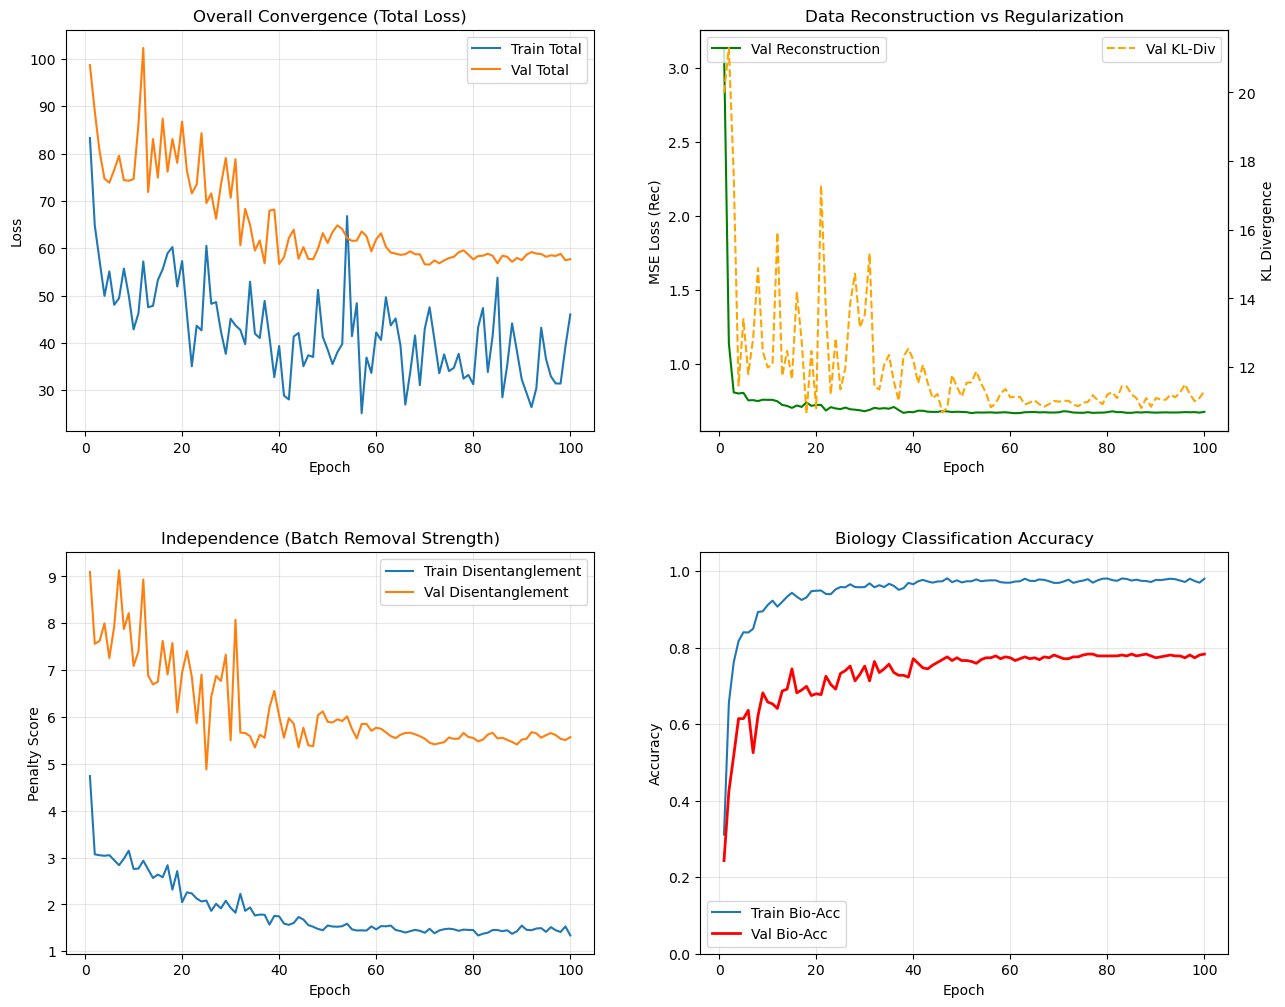

In [92]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

def plot_training_results(trainer):
    # 1. 데이터 정리
    history = trainer.history
    epochs = [h['epoch'] for h in history]
    
    # 지표 추출 함수
    def get_metric(phase, key):
        return [h[phase][key] for h in history]

    # 시각화 레이아웃 설정 (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.3)
    # (1) Total Loss: 전체적인 수렴 확인
    axes[0, 0].plot(epochs, get_metric('train', 'total'), label='Train Total')
    axes[0, 0].plot(epochs, get_metric('val', 'total'), label='Val Total')
    axes[0, 0].set_title('Overall Convergence (Total Loss)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    # (2) Reconstruction & KL: VAE 본연의 성능
    axes[0, 1].plot(epochs, get_metric('val', 'rec'), label='Val Reconstruction', color='green')
    ax2 = axes[0, 1].twinx() # KL은 scale이 다를 수 있음
    ax2.plot(epochs, get_metric('val', 'kl'), label='Val KL-Div', color='orange', linestyle='--')
    axes[0, 1].set_title('Data Reconstruction vs Regularization')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('MSE Loss (Rec)')
    ax2.set_ylabel('KL Divergence')
    axes[0, 1].legend(loc='upper left')
    ax2.legend(loc='upper right')
    # (3) Disentanglement Loss: Batch 효과 제거 성능
    axes[1, 0].plot(epochs, get_metric('train', 'dis'), label='Train Disentanglement')
    axes[1, 0].plot(epochs, get_metric('val', 'dis'), label='Val Disentanglement')
    axes[1, 0].set_title('Independence (Batch Removal Strength)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Penalty Score')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    # (4) Biology Accuracy: 분류 성능 (가장 중요!)
    axes[1, 1].plot(epochs, get_metric('train', 'acc'), label='Train Bio-Acc')
    axes[1, 1].plot(epochs, get_metric('val', 'acc'), label='Val Bio-Acc', linewidth=2, color='red')
    axes[1, 1].set_title('Biology Classification Accuracy')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy')
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.show()

# 실행
plot_training_results(trainer)

Extracting:   0%|          | 0/13 [00:00<?, ?it/s]

Extracting:   0%|          | 0/4 [00:00<?, ?it/s]

🧬 Train - z_bio: t-SNE 및 PCA 계산 중...


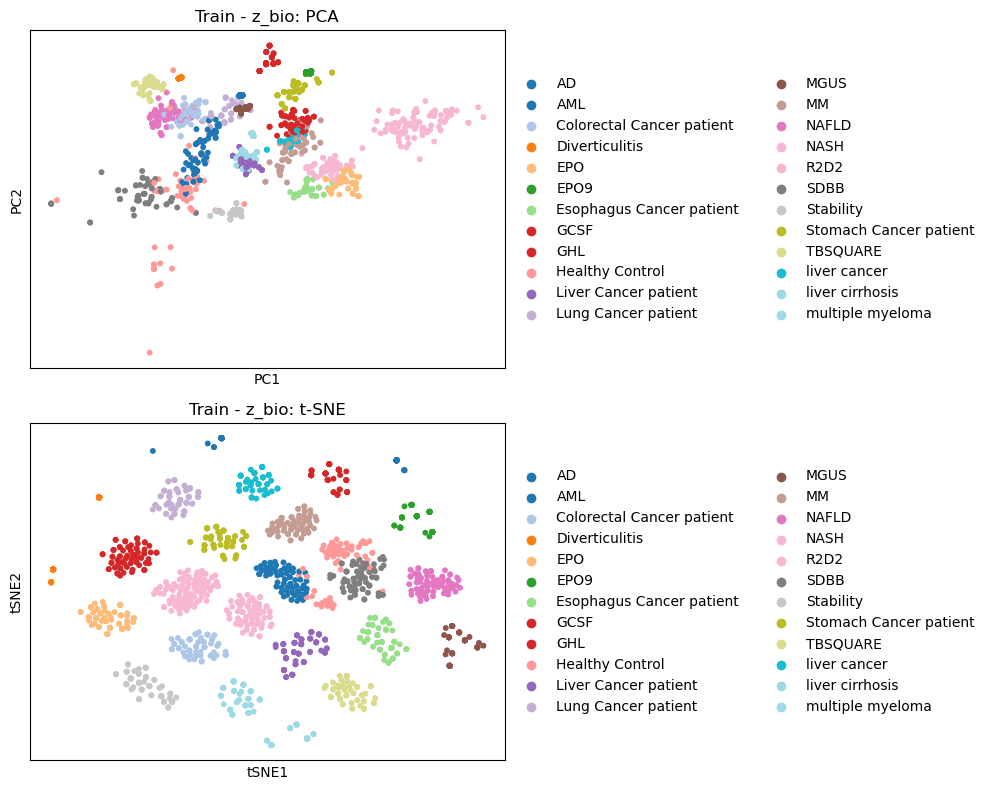

🧬 Train - X_cleaned: PCA 기반 t-SNE 계산 중...


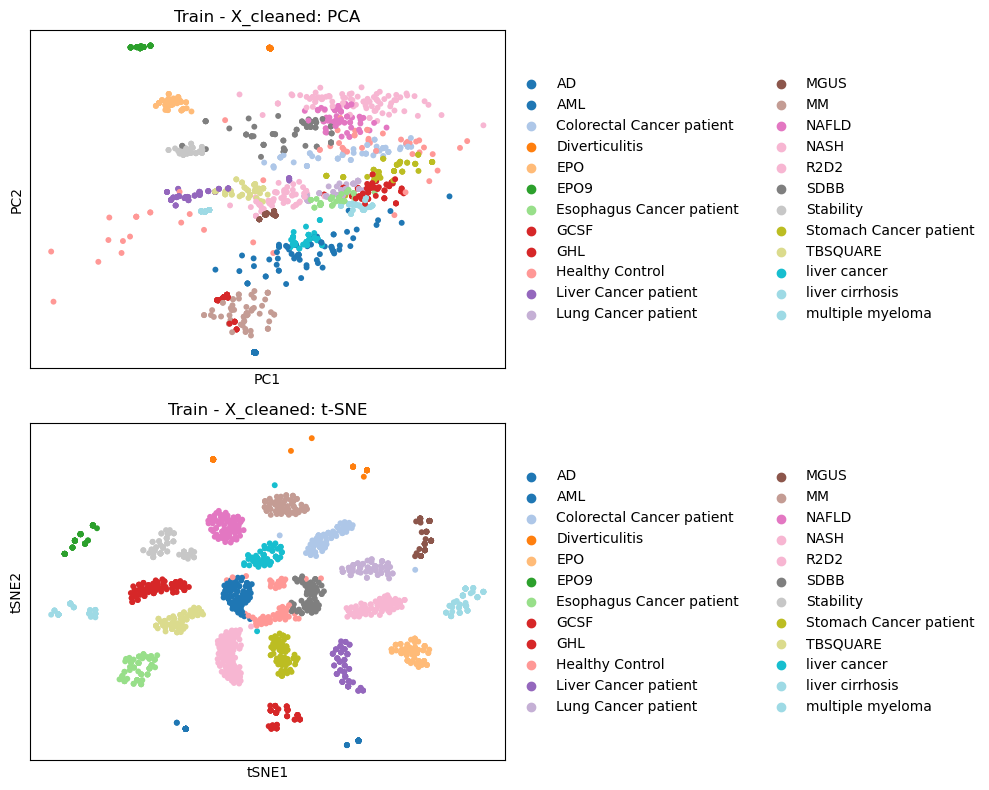

🧬 Val - z_bio: t-SNE 및 PCA 계산 중...


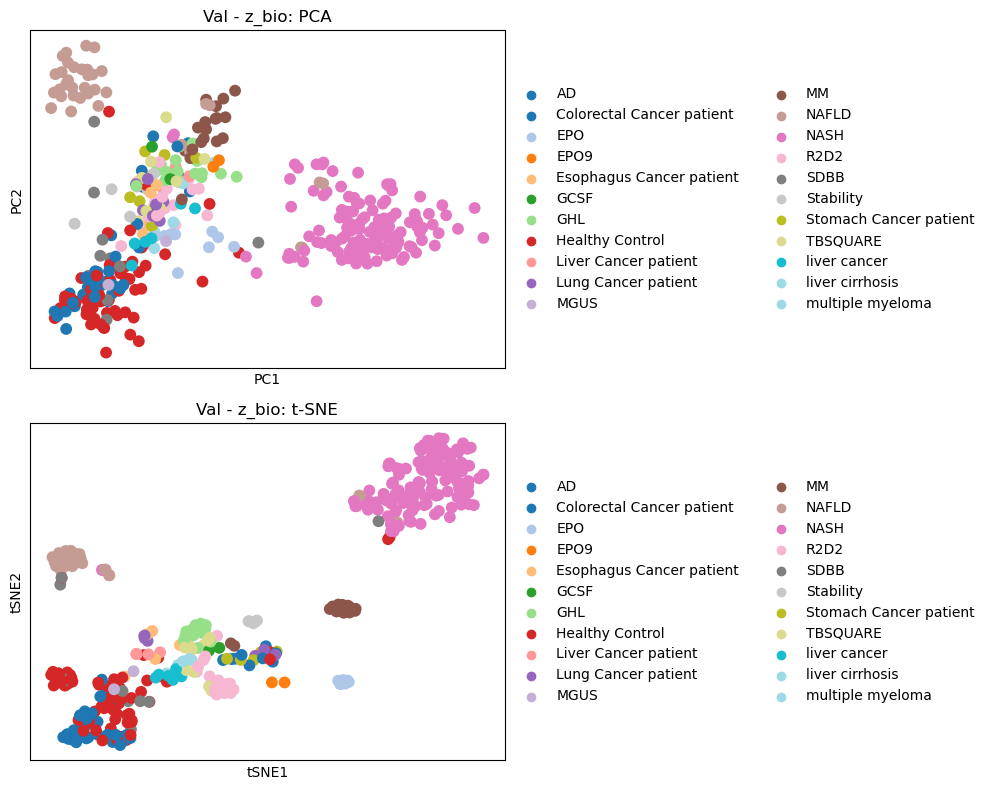

🧬 Val - X_cleaned: PCA 기반 t-SNE 계산 중...


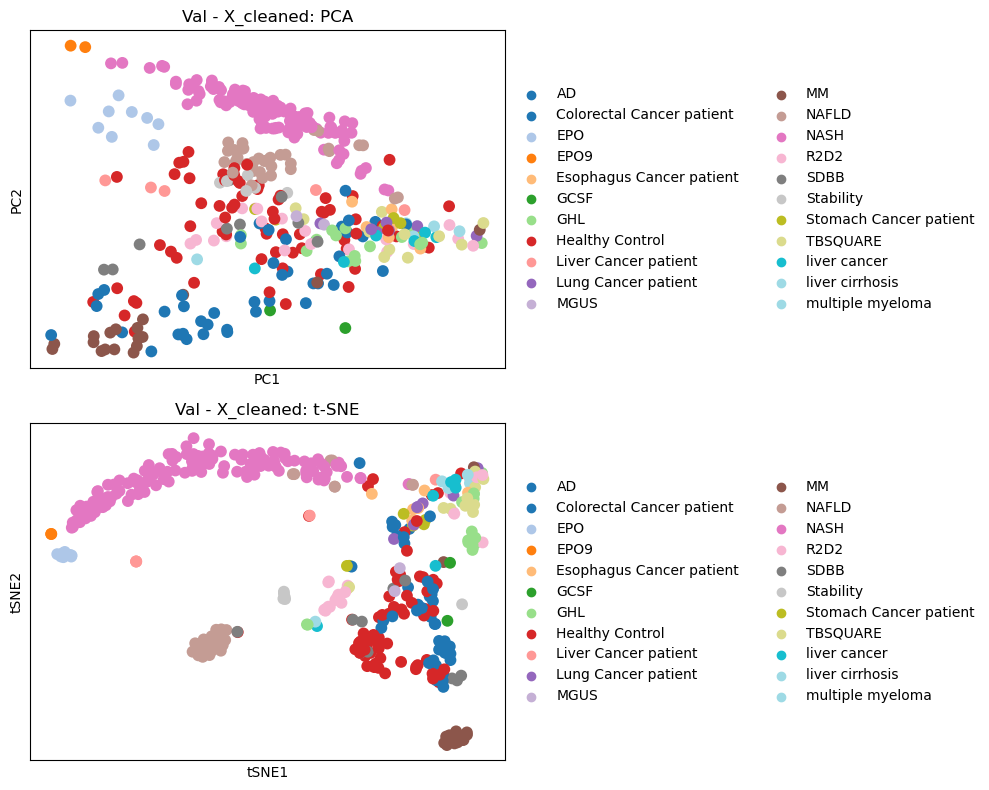

In [93]:
import scanpy as sc
import matplotlib.pyplot as plt
def run_viz_pipeline(adata, title_prefix):
    # --- [공간 1: z_bio] (Latent Space) ---
    print(f"🧬 {title_prefix} - z_bio: t-SNE 및 PCA 계산 중...")
    
    # z_bio 전용 임시 AnnData 생성 (Shape 충돌 방지)
    adata_z = sc.AnnData(X=adata.obsm['X_z_bio'])
    adata_z.obs = adata.obs.copy()
    
    # PCA 및 t-SNE 계산
    sc.tl.pca(adata_z, n_comps=min(31, adata_z.n_obs-1))
    sc.tl.tsne(adata_z, use_rep='X_pca', perplexity=30, random_state=42)
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    sc.pl.pca(adata_z, color='Phenotype', ax=axes[0], show=False, palette='tab20', 
              title=f"{title_prefix} - z_bio: PCA")
    sc.pl.tsne(adata_z, color='Phenotype', ax=axes[1], show=False, 
               title=f"{title_prefix} - z_bio: t-SNE", palette='tab20')
    plt.tight_layout()
    plt.show()

    # --- [공간 2: x_cleaned] (Expression Space) ---
    print(f"🧬 {title_prefix} - X_cleaned: PCA 기반 t-SNE 계산 중...")
    
    # 원본 adata(x_cleaned가 들어있는) 사용
    sc.tl.pca(adata, n_comps=50) 
    sc.tl.tsne(adata, use_rep='X_pca', perplexity=30, random_state=42)
    
    fig, axes = plt.subplots(2, 1, figsize=(10, 8))
    sc.pl.pca(adata, color='Phenotype', ax=axes[0], show=False, palette='tab20',
              title=f"{title_prefix} - X_cleaned: PCA")
    sc.pl.tsne(adata, color='Phenotype', ax=axes[1], show=False, 
               title=f"{title_prefix} - X_cleaned: t-SNE", palette='tab20')
    plt.tight_layout()
    plt.show()

train_adata = trainer.get_ann_data(train_loader, class_names=class_names)
val_adata = trainer.get_ann_data(val_loader, class_names=class_names)
run_viz_pipeline(train_adata, "Train")
run_viz_pipeline(val_adata, "Val")

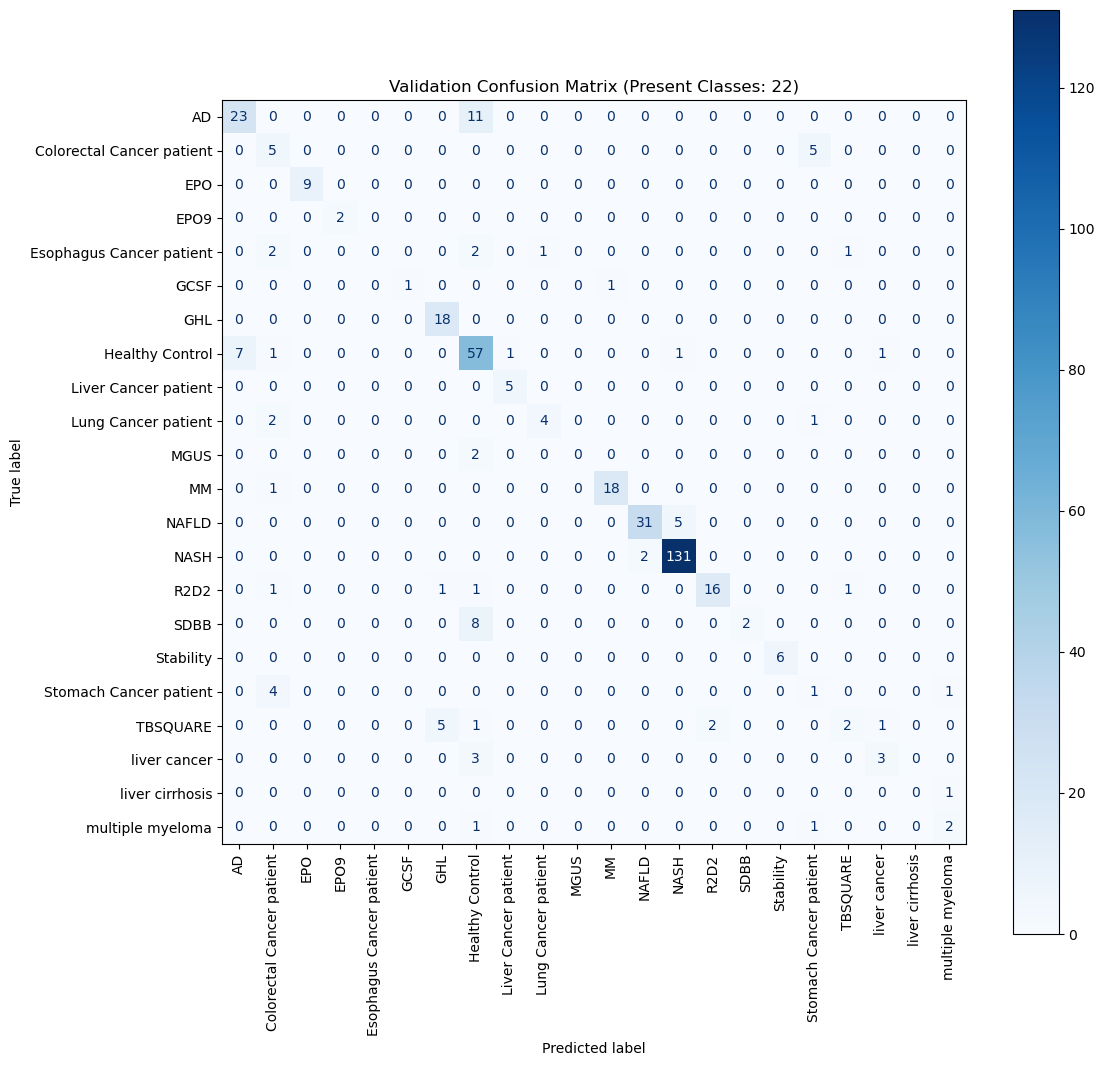

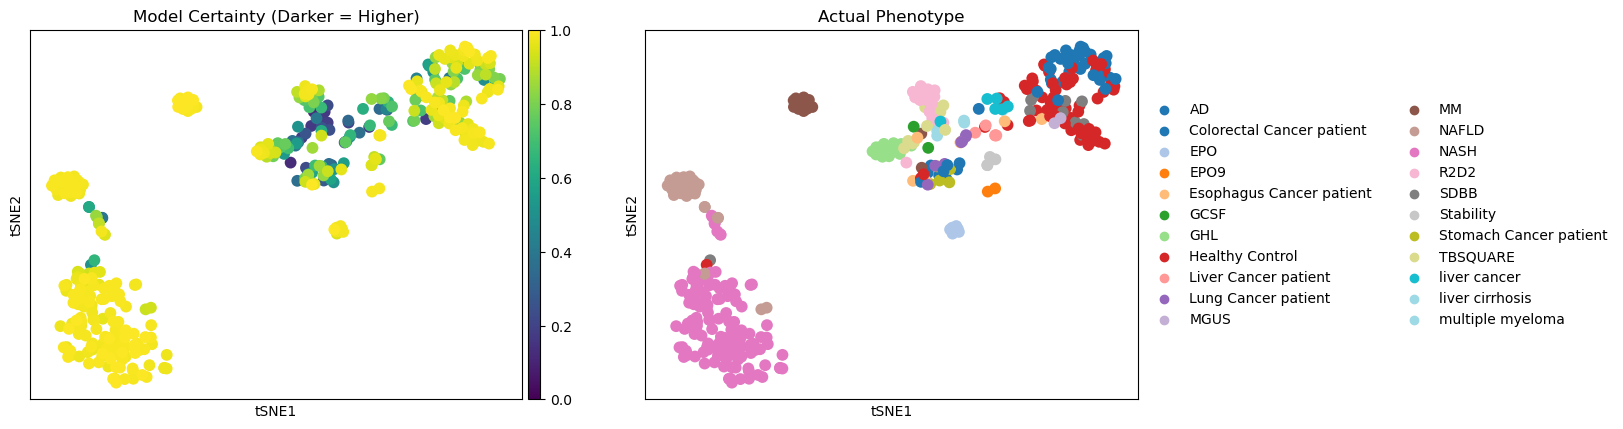

🎨 Validation - Batch Effect 분석 (t-SNE) ...


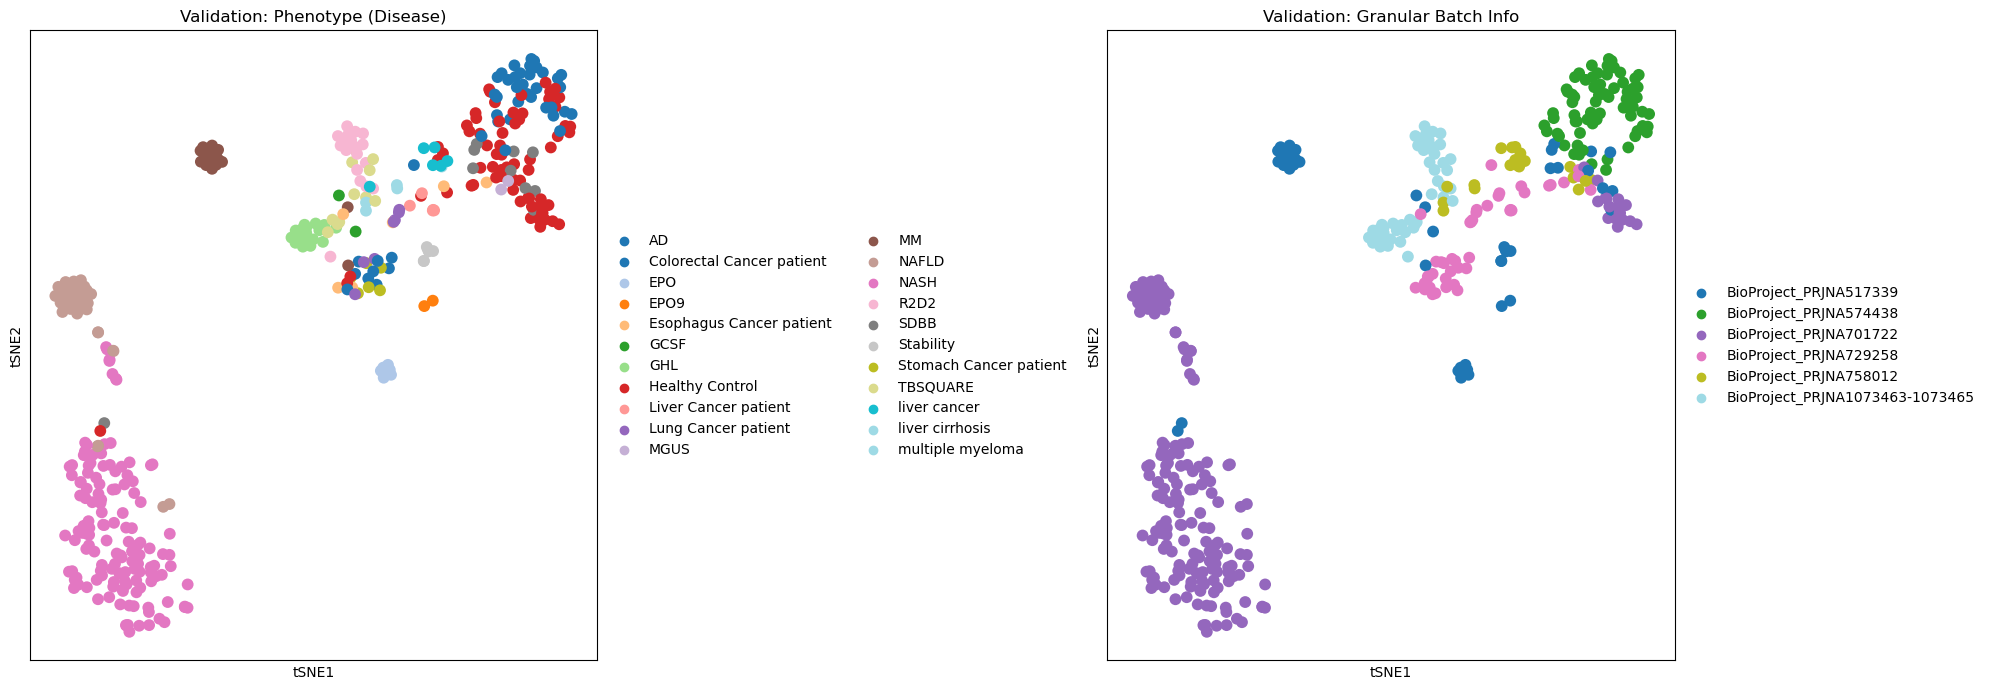

In [90]:
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
import scanpy as sc
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- 1. Confusion Matrix (이전과 동일) ---
present_indices = np.unique(np.concatenate([y_true, y_pred_label]))
present_class_names = [class_names[i] for i in present_indices]
cm = confusion_matrix(y_true, y_pred_label, labels=present_indices)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present_class_names)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=90)
plt.title(f"Validation Confusion Matrix (Present Classes: {len(present_indices)})")
plt.show()

probs = scipy.special.softmax(res['y_pred'], axis=1)
confidence = probs.max(axis=1)
val_adata.obs['Confidence'] = confidence
val_adata.obs['Predicted_Label'] = [class_names[i] for i in y_pred_label]
sc.tl.tsne(val_adata, use_rep='X_z_bio', perplexity=30, random_state=42)

sc.pl.tsne(val_adata, 
           color=['Confidence', 'Phenotype'], 
           title=['Model Certainty (Darker = Higher)', 'Actual Phenotype'],
           cmap='viridis', 
           vmin=0, vmax=1,
           palette='tab20') # 세로로 나란히 배치하여 비교 용이하게 설정

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

batch_dummy_cols = pd.get_dummies(batch_df, columns=batch_cols, dtype=float).columns
val_c_tensor = val_loader.dataset.c
n_bias = len(bias_metrics) # gc_bias_score 등 8개
val_batch_part = val_c_tensor[:, n_bias:].cpu().numpy()
val_batch_indices = np.argmax(val_batch_part, axis=1)
val_batch_labels = [batch_dummy_cols[i] for i in val_batch_indices]
val_adata.obs['Granular_Batch'] = val_batch_labels
def plot_batch_effect_tsne(adata, title_prefix):
    print(f"🎨 {title_prefix} - Batch Effect 분석 (t-SNE) ...")
    if 'X_tsne' not in adata.obsm:
        print("   (t-SNE 좌표 계산 중...)")
        sc.tl.tsne(adata, use_rep='X_z_bio', perplexity=30, random_state=42)
    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    sc.pl.tsne(adata, color='Phenotype', ax=axes[0], show=False, 
               title=f"{title_prefix}: Phenotype (Disease)", palette='tab20')
    sc.pl.tsne(adata, color='Granular_Batch', ax=axes[1], show=False, 
               title=f"{title_prefix}: Granular Batch Info", palette='tab20')
    plt.tight_layout()
    plt.show()

# 실행
plot_batch_effect_tsne(val_adata, "Validation")